# Imports

In [1]:
import seaborn as sns
from matplotlib import pyplot as plt

from alphaanalysis.plot.gam import get_sig_intervals
import utils

# Data Base

In [2]:
from djimaging.user.alpha.utils import access_database

indicator = 'glutamate'

database = access_database.access_database(indicator, use_sql=False)
df = database.get_tri_df()
df = df.drop(columns=['chirp_avg', 'trf'])

Loading glutamate data from: /gpfs01/berens/user/joesterle/projects/alpha/__public_s-on-alpha-regional/gnode/s-on-alpha-regional/database-exports/Ran/sONa_glutamate


# Plot

In [3]:
from alphaanalysis import plot as plota
plota.set_rc_params()

In [4]:
order = plota.get_order(indicator=indicator)
palette = plota.get_palette(indicator=indicator)
colors = [palette[group] for group in order]

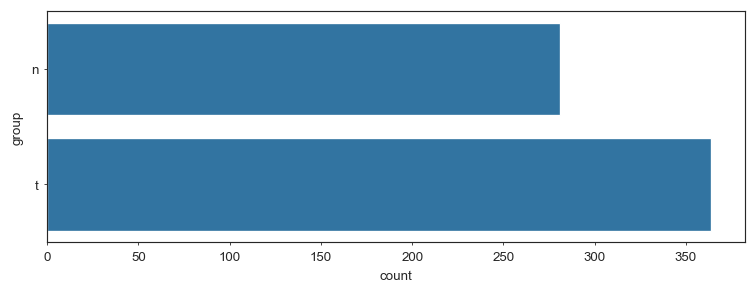

In [5]:
sns.countplot(data=df, y="group");

# Fit GAM

In [6]:
%load_ext rpy2.ipython

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 
6: Setting LC_PAPER failed, using "C" 
7: Setting LC_MEASUREMENT failed, using "C" 


In [7]:
%%R

rm(list=ls()) 

In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library '/usr/lib/R/site-library' contains no packages


## R imports

In [8]:
#!sudo apt-get update
#!sudo apt-get install -y libfontconfig1-dev
# !sudo apt-get install -y libcairo2-dev

In [9]:
#!sudo Rscript -e 'install.packages("IRdisplay")'
#!sudo Rscript -e 'install.packages("dplyr")'
#!sudo Rscript -e 'install.packages("parallel")'
#!sudo Rscript -e 'install.packages("ggplot2")'
#!sudo Rscript -e 'install.packages("nlme")'
#!sudo Rscript -e 'install.packages("mgcv")'
#!sudo Rscript -e 'install.packages("hrbrthemes")'
#!sudo Rscript -e 'install.packages("ggthemes")'
#!sudo Rscript -e 'install.packages("itsadug")'
#!sudo Rscript -e 'install.packages("png")'
#!sudo Rscript -e 'install.packages("xtable")'
#!sudo Rscript -e 'install.packages("tidymv")'
#!sudo Rscript -e 'install.packages("cowplot")'

In [10]:
%%R

library("IRdisplay")
library("dplyr")
library('parallel')
library('ggplot2')
library("nlme")
library("mgcv")
# library("hrbrthemes")
library("ggthemes")
library("itsadug")
library("png")
library("xtable")
library("tidymv")
library("cowplot")


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Attaching package: 'nlme'

The following object is masked from 'package:dplyr':

    collapse

This is mgcv 1.9-0. For overview type 'help("mgcv-package")'.
Loading required package: plotfunctions

Attaching package: 'plotfunctions'

The following object is masked from 'package:ggplot2':

    alpha

Loaded package itsadug 2.4 (see 'help("itsadug")' ).

Attaching package: 'xtable'

The following object is masked from 'package:IRdisplay':

    display

tidymv has been superseded by tidygam. The package tidymv is no longer maintained but will be
    kept on CRAN to ensure reproducibility of older analyses. Users should
    use the replacement package tidygam for new analyses, which is available on
    CRAN and GitHub (https://github.com/stefanocoretta/tidygam).

Attaching package: 'tidymv'

Th

# Import R df

In [11]:
%%R -i df

df$group <- factor(df$group)
df$cell_id <- factor(df$cell_id)
df$field_id <- factor(df$field_id)


df <- df[df$soma_dist <= 200, ]

head(df)

  experimenter   date exp_num field   cond1 roi_id      cell_id        field_id
0          Ran 737732       1    d1 control      1 2020-11-03_1 2020-11-03_1_d1
1          Ran 737732       1    d1 control      2 2020-11-03_1 2020-11-03_1_d1
2          Ran 737732       1    d1 control      3 2020-11-03_1 2020-11-03_1_d1
3          Ran 737732       1    d1 control      4 2020-11-03_1 2020-11-03_1_d1
4          Ran 737732       1    d1 control      5 2020-11-03_1 2020-11-03_1_d1
5          Ran 737732       1    d1 control      6 2020-11-03_1 2020-11-03_1_d1
  lChirp gChirp chirp_tri     qidx min_qidx chirp_surround_index soma_dist
0 lChirp gChirp 0.3518270 0.701910 0.333333            -0.246786   95.1105
1 lChirp gChirp 0.0586807 0.671410 0.333333            -1.035450   98.8116
2 lChirp gChirp       NaN 0.718814 0.333333            -1.273710  112.2100
3 lChirp gChirp 0.4561130 0.718288 0.333333            -1.404070  114.9270
4 lChirp gChirp       NaN 0.639463 0.333333            -1.369130 

## Helper functions

In [12]:
%%R

display_model <- function(m){
    print(summary(m));
    tabs <- capture.output(gamtabs(m, type="HTML"));
    display_html(tabs);
}

## Plot raw data

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: Removed 148 rows containing missing values (`geom_point()`). 



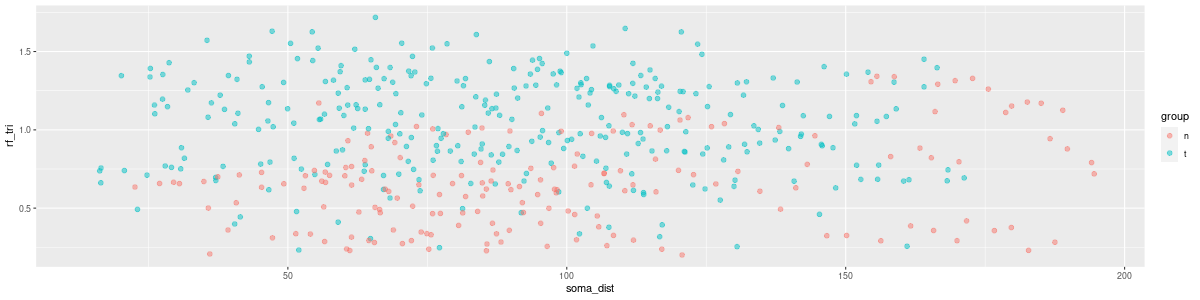

In [13]:
%%R -w 1200 -h 300

p1 <- ggplot(aes(x=soma_dist, y=rf_tri, color=group), data=df)  +
    geom_point(alpha=.5, size=2)

p1

# GAMs

## Noise TRi

In [14]:
%%R

m1  <- gam(rf_tri ~ group + s(soma_dist, k=4, bs="cr"), data=df)
m2  <- gam(rf_tri ~ group + s(soma_dist, by=group, k=4, bs="cr"), data=df)
m3a <- gam(rf_tri ~ group + s(soma_dist, by=group, k=4, bs="cr") + s(cell_id, bs="re"), data=df)
m3b <- gam(rf_tri ~ group + s(soma_dist, by=group, k=4, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')
m4a <- gam(rf_tri ~ group + s(soma_dist, by=group, k=8, bs="cr") + s(cell_id, bs="re"), data=df)
m4b <- gam(rf_tri ~ group + s(soma_dist, by=group, k=8, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')
m5a <- gam(rf_tri ~ group + s(soma_dist, by=group, k=12, bs="cr") + s(cell_id, bs="re"), data=df)
m5b <- gam(rf_tri ~ group + s(soma_dist, by=group, k=12, bs="cr") + s(cell_id, bs="re"), data=df, family='scat')

In [15]:
%%R
BIC(m1, m2, m3a, m3b, m4a, m4b, m5a, m5b)

           df       BIC
m1   4.000000 233.28433
m2   5.782214 226.01365
m3a 14.642675  25.10898
m3b 15.992457  12.48024
m4a 14.642744  25.10927
m4b 15.992464  12.48029
m5a 14.642744  25.10927
m5b 15.992459  12.48025


In [16]:
%%R
anova(m1, m2, m3a, m4a, m5a, test="F")

Analysis of Deviance Table

Model 1: rf_tri ~ group + s(soma_dist, k = 4, bs = "cr")
Model 2: rf_tri ~ group + s(soma_dist, by = group, k = 4, bs = "cr")
Model 3: rf_tri ~ group + s(soma_dist, by = group, k = 4, bs = "cr") + 
    s(cell_id, bs = "re")
Model 4: rf_tri ~ group + s(soma_dist, by = group, k = 8, bs = "cr") + 
    s(cell_id, bs = "re")
Model 5: rf_tri ~ group + s(soma_dist, by = group, k = 12, bs = "cr") + 
    s(cell_id, bs = "re")
  Resid. Df Resid. Dev         Df Deviance       F    Pr(>F)    
1    487.00     43.906                                          
2    484.82     42.296 2.1753e+00   1.6104 14.0528 4.893e-07 ***
3    476.01     25.095 8.8100e+00  17.2008 37.0614 < 2.2e-16 ***
4    476.01     25.095 5.6977e-06   0.0000 24.4877 2.563e-05 ***
5    476.01     25.095 7.7167e-09   0.0000  5.6182 6.587e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [17]:
%%R
anova(m3b, m4b, m5b, test="F")

Analysis of Deviance Table

Model 1: rf_tri ~ group + s(soma_dist, by = group, k = 4, bs = "cr") + 
    s(cell_id, bs = "re")
Model 2: rf_tri ~ group + s(soma_dist, by = group, k = 8, bs = "cr") + 
    s(cell_id, bs = "re")
Model 3: rf_tri ~ group + s(soma_dist, by = group, k = 12, bs = "cr") + 
    s(cell_id, bs = "re")
  Resid. Df Resid. Dev          Df    Deviance  Pr(>Chi)    
1    475.76    -86.584                                      
2    475.76    -86.584  1.1210e-05  1.2041e-06 7.704e-05 ***
3    475.76    -86.584 -8.4664e-06 -5.5713e-07 6.145e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



Family: Scaled t(5.015,0.182) 
Link function: identity 

Formula:
rf_tri ~ group + s(soma_dist, by = group, k = 4, bs = "cr") + 
    s(cell_id, bs = "re")

Parametric coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.6627     0.1010   6.564 5.24e-11 ***
groupt        0.3840     0.1320   2.909  0.00362 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                      edf Ref.df  Chi.sq p-value    
s(soma_dist):groupn 1.000      1  59.498  <2e-16 ***
s(soma_dist):groupt 1.000      1   0.289   0.591    
s(cell_id)          9.744     10 441.694  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =   0.56   Deviance explained = 53.9%
-REML = -9.0099  Scale est. = 1         n = 490

Method: REML   Optimizer: outer newton
full convergence after 15 iterations.
Gradient range [-4.621321e-06,-1.185985e-08]
(score -9.009916 & scale 1).
Hessian positive def

In addition: Warning message:
In getOption("jupyter.base_display_func")(data, metadata) :
  IRdisplay can only be used from the IPython R kernel and R magic.


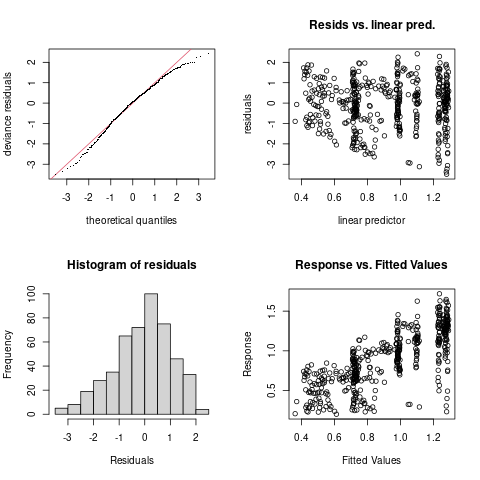

In [18]:
%%R
m <- m3b
display_model(m)
gam.check(m)

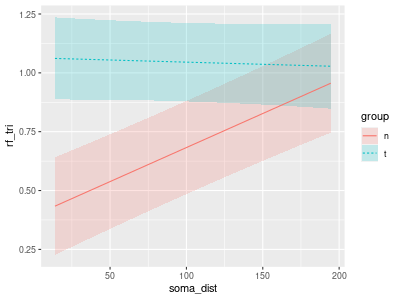

In [19]:
%%R -w 400 -h 300

p1 <- plot_smooths(model=m, series=soma_dist, comparison=group)
plot(p1, ylim=c(0, 60))

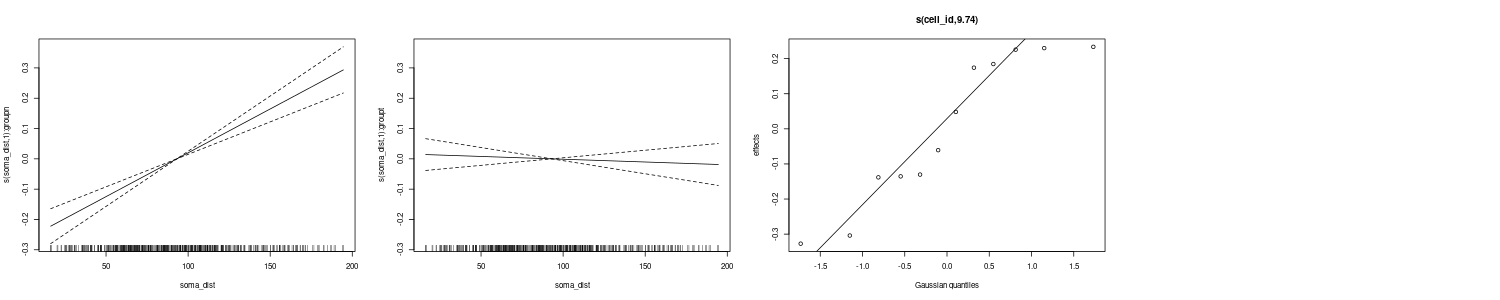

In [20]:
%%R -w 1500 -h 300
par(mfrow = c(1,4))
plot(m)

### Plot fits

In [21]:
%%R

r_df_pred = predict_gam(m, exclude_terms=s(cell_id, bs="re"))
head(r_df_pred)

# A tibble: 6 x 5
  group soma_dist cell_id        fit se.fit
  <fct>     <dbl> <fct>        <dbl>  <dbl>
1 n          13.9 2020-11-03_1 0.434 0.106 
2 t          13.9 2020-11-03_1 1.06  0.0890
3 n          17.6 2020-11-03_1 0.444 0.105 
4 t          17.6 2020-11-03_1 1.06  0.0887
5 n          21.3 2020-11-03_1 0.455 0.105 
6 t          21.3 2020-11-03_1 1.06  0.0883


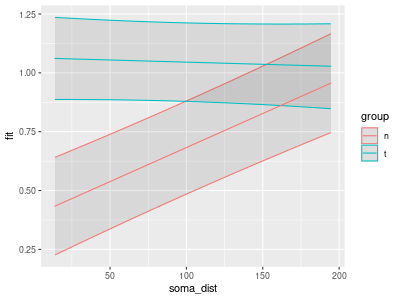

In [22]:
%%R -w 400 -h 300

predict_gam(m, exclude_terms=s(cell_id, bs="re")) %>%
    ggplot(aes(soma_dist, fit, col=group)) +
    geom_smooth_ci()

### Plot differences 

[1] 1.959964
Summary:
	* soma_dist : numeric predictor; with 100 values ranging from 16.268800 to 194.552000. 
	* cell_id : factor; set to the value(s): 2020-11-03_1. (Might be canceled as random effect, check below.) 
	* NOTE : The following random effects columns are canceled: s(cell_id)
 

soma_dist window(s) of significant difference(s):
	16.268800 - 131.522586


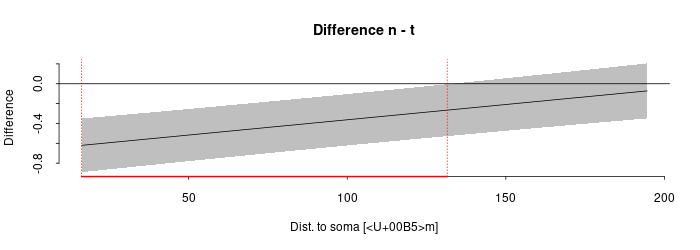

In [23]:
%%R -w 700 -h 250 -o nt_diff

n_diffs <- 1
par(mfrow=c(1, n_diffs), cex=1.0, tcl=-0.2)

se <- qnorm((100 - (2.5/n_diffs))/100)
print(se)
ylim <- NULL#c(-150, 150)
ylab <- 'Difference'
xlab <- 'Dist. to soma [µm]'

nt_diff <- plot_diff(m, view="soma_dist", comp=list(group=c("n", "t")), se=se, ylab=ylab, xlab=xlab, ylim=ylim, hide.label=TRUE)

In [24]:
pairs_sig_regions = [
    ("n vs. t  ", get_sig_intervals(nt_diff)),
]
pairs_sig_regions

[]
[ 0 64]


[('n vs. t  ', [(16.2688, 131.52258585858584)])]

# Go back to python for easy plotting

In [25]:

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

with localconverter(ro.default_converter + pandas2ri.converter):
    df_pred = ro.conversion.rpy2py(ro.globalenv['r_df_pred'])

In [26]:
df_pred.head()

,group,soma_dist,cell_id,fit,se.fit
1,n,13.909000,2020-11-03_1,0.433672,0.105826
2,t,13.909000,2020-11-03_1,1.061253,0.089023
3,n,17.595592,2020-11-03_1,0.444334,0.105419
4,t,17.595592,2020-11-03_1,1.060577,0.088658
5,n,21.282184,2020-11-03_1,0.454996,0.105029


(2.5, 1.8)


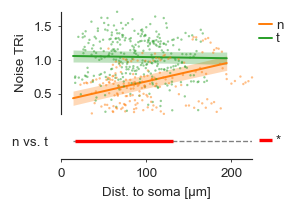

In [27]:
fig, axs = utils.plot_fits(
    df=df,
    df_preds=[df_pred],
    pairs_sig_regions_list=[pairs_sig_regions],
    titles=[None],
    ys=['rf_tri'],
    ylabels=['Noise TRi'],
    x='soma_dist',
    xlabel='Dist. to soma [µm]',
    order=order, colors=colors,
    figsize=(2.5, 1.8), ms=2, ma=0.5
)
plt.tight_layout()
plt.savefig(f'figures/{indicator}_rf_tri_soma_dist.pdf')
plt.show()